# pyissm Plotting Tutorial

This notebook demonstrates the `pyissm.plot` API using a minimal square ice-shelf model
built from the CI test suite — no solver run is needed.

| Function | Description |
|---|---|
| `plot_mesh2d(md)` | Unstructured triangular mesh |
| `plot_model_field(md, field)` | Scalar field on the mesh |
| `plot_model_nodes(md, ...)` | Node classification by levelset |
| `plot_model_bc(md)` | Dirichlet boundary conditions |
| `plot_contour(md, field, ...)` | Contour overlay on an existing axes |
| `plot_quiver(md, vx, vy, ...)` | Velocity arrow plot |
| `plot_streamlines(md, vx, vy, ...)` | Streamline traces |
| `plot_gridded(md, field, ...)` | Regular-grid interpolation |
| `plot_elementnumbering(md)` | Element index labels |
| `plot_vertexnumbering(md)` | Vertex index labels |
| `plot_icefront(md)` | Ice-front / grounding-line elements |
| `pyissm.plot.colormaps` | ISSM-compatible colormaps (`demmap`, `seacolor`, …) |

All functions that create a new figure return `(fig, ax[, im])`.  
When you pass an existing `ax=` they return `(ax[, im])`, enabling free composition
inside any matplotlib subplot grid.

## Setup

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import pyissm
print('pyissm:', pyissm.__version__)
print(sys.version.split()[0])

pyissm: 0.0.1.dev260219
3.11.14


## Build model

Parameterise a square ice-shelf — no solve needed for plotting.

In [ ]:
md = pyissm.model.mesh.triangle(
    pyissm.model.Model(),
    '../assets/Exp/Square.exp',
    50000   # mesh resolution [m]
)
md = pyissm.model.param.set_mask(md, 'all', None)
md = pyissm.model.param.parameterize(md, '../assets/Par/SquareShelfConstrained.py')
md = pyissm.model.param.set_flow_equation(md, SSA='all')

speed = np.sqrt(md.initialization.vx**2 + md.initialization.vy**2)

print(f'Vertices : {md.mesh.numberofvertices}')
print(f'Elements : {md.mesh.numberofelements}')
print(f'vx range : {md.initialization.vx.min():.1f} → {md.initialization.vx.max():.1f} m/yr')

Vertices : 340
Elements : 614
vx range : -227.4 → 220.7 m/yr


---
## 1  Mesh plot

Plot the unstructured triangular mesh.

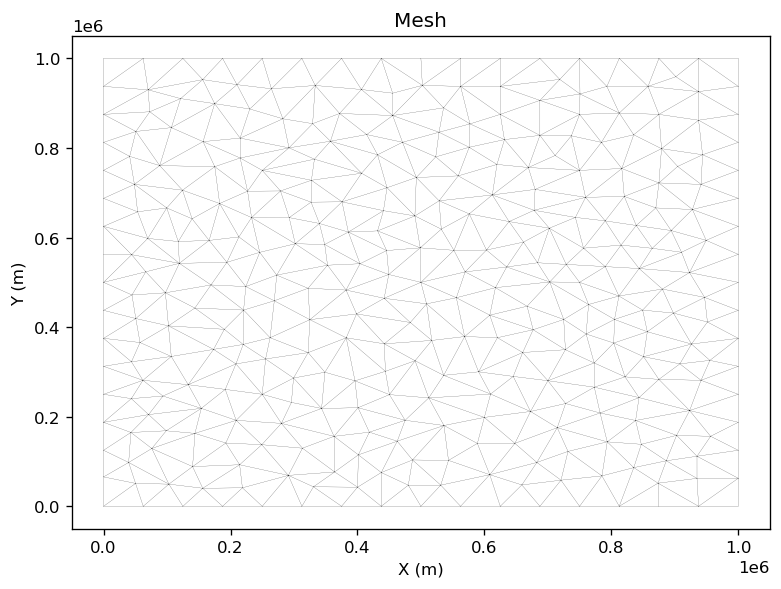

In [3]:
fig, ax = pyissm.plot.plot_mesh2d(md)
ax.set_title('Mesh')
plt.show()

---
## 2  Scalar field

Colour the mesh elements by a scalar field — here velocity magnitude.

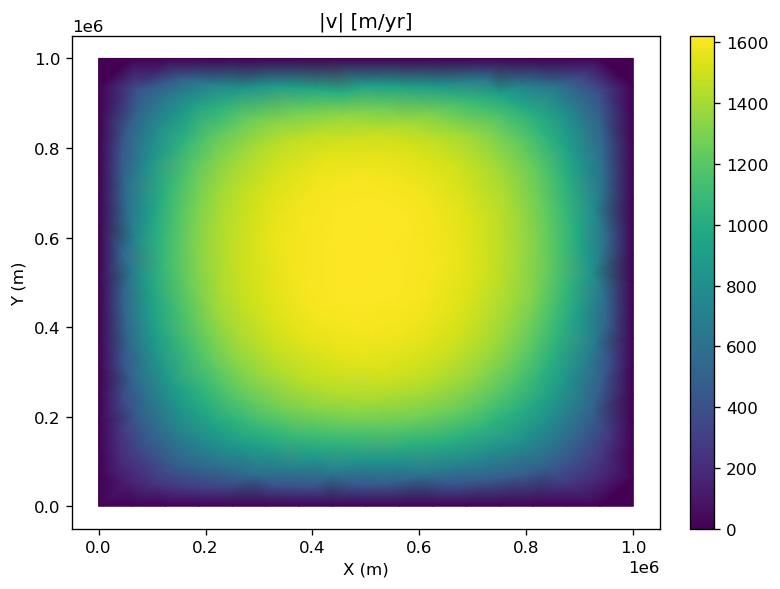

In [4]:
fig, ax, im = pyissm.plot.plot_model_field(md, speed, colormap='viridis', show_cbar=True)
ax.set_title('|v| [m/yr]')
plt.show()

---
## 3  Node / element classification

Colour-code nodes as grounded, floating, or ice-free using the levelset arrays.

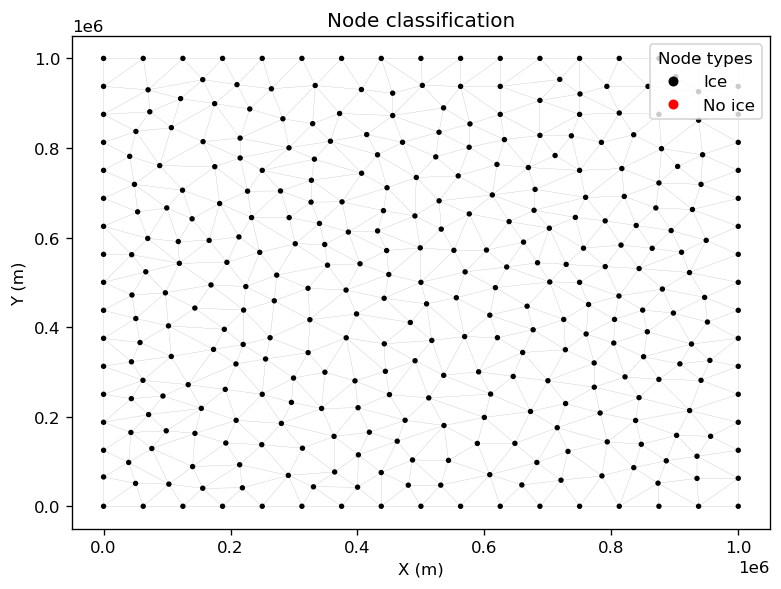

In [5]:
fig, ax = pyissm.plot.plot_model_nodes(
    md,
    ice_levelset=md.mask.ice_levelset,
    ocean_levelset=md.mask.ocean_levelset
)
ax.set_title('Node classification')
plt.show()

---
## 4  Boundary conditions

Show Dirichlet velocity constraints and ice-front elements.

No ice-front (Neumann) elements found to plot.


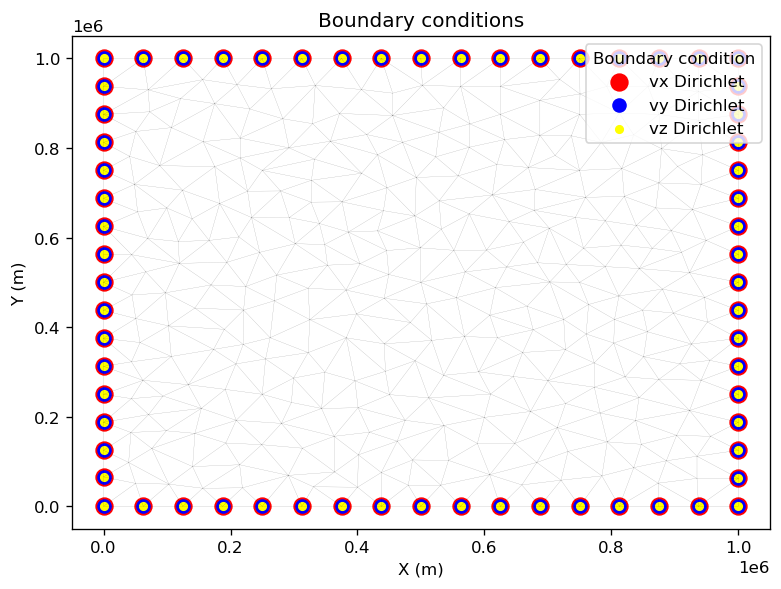

In [6]:
fig, ax = pyissm.plot.plot_model_bc(md)
ax.set_title('Boundary conditions')
plt.show()

---
## 5  Contour overlay

Overlay contour lines on a colour plot by passing `ax=` to `plot_contour`.

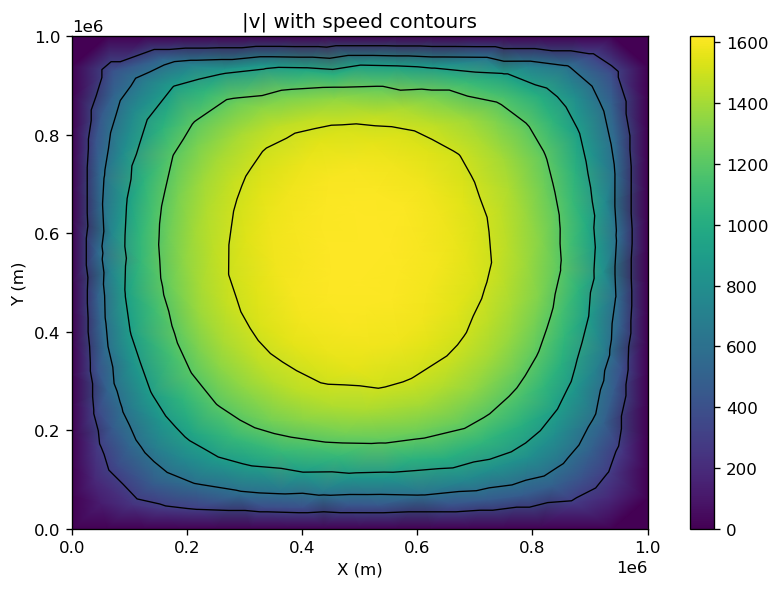

In [7]:
fig, ax, im = pyissm.plot.plot_model_field(md, speed, colormap='viridis', show_cbar=True)
pyissm.plot.plot_contour(
    md, speed,
    levels=5, ax=ax,
    colors='k', linewidths=0.8,
)
ax.set_title('|v| with speed contours')
plt.show()

---
## 6  Quiver plot

Arrow plot of velocity direction and magnitude.

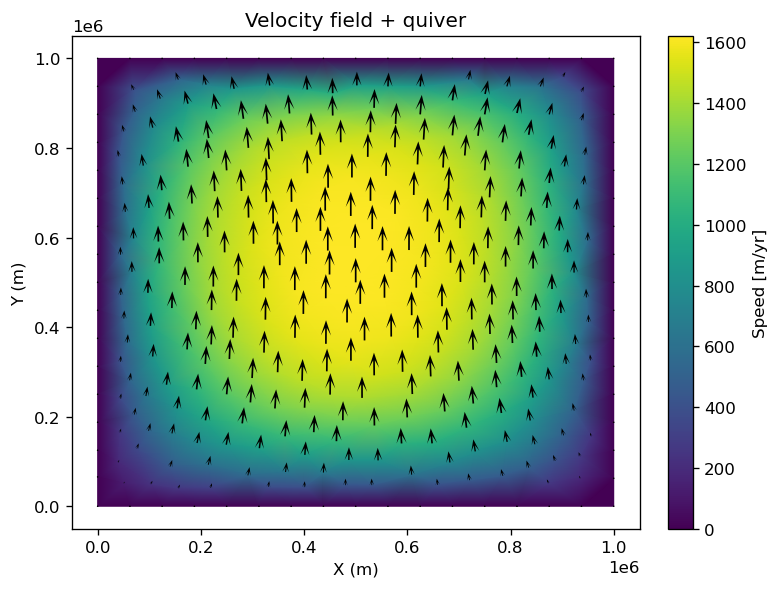

In [8]:
fig, ax, im = pyissm.plot.plot_model_field(
    md, speed, colormap='viridis', show_mesh=False
)
pyissm.plot.plot_quiver(
    md,
    vx=md.initialization.vx,
    vy=md.initialization.vy,
    ax=ax, color='k', width=3e-3
)
ax.set_title('Velocity field + quiver')
fig.colorbar(im, ax=ax, label='Speed [m/yr]')
plt.show()

---
## 7  Streamlines

Trace flow lines through the velocity field.

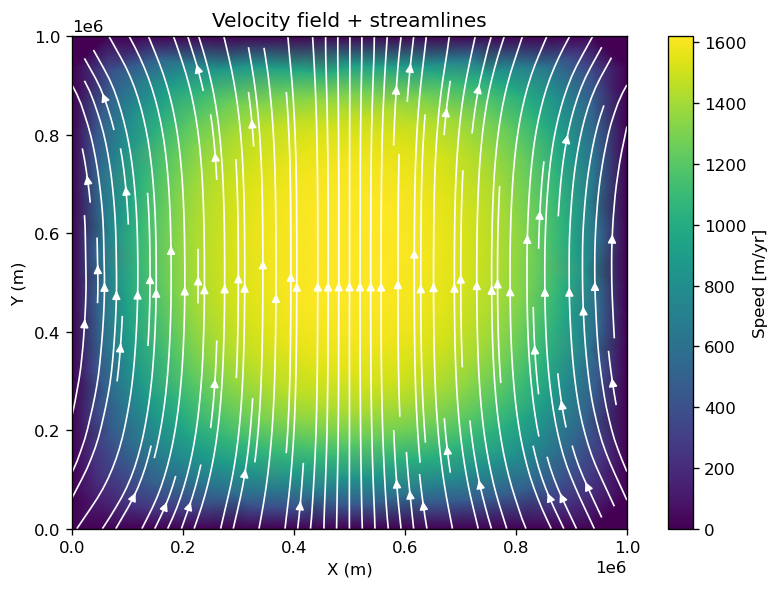

In [9]:
fig, ax, im = pyissm.plot.plot_model_field(
    md, speed, colormap='viridis', show_mesh=False
)
pyissm.plot.plot_streamlines(
    md,
    vx=md.initialization.vx,
    vy=md.initialization.vy,
    ax=ax, color='w', density=1.5
)
ax.set_title('Velocity field + streamlines')
fig.colorbar(im, ax=ax, label='Speed [m/yr]')
plt.show()

---
## 8  Gridded interpolation

Interpolate an unstructured-mesh field to a regular grid (`scipy.interpolate.griddata`).

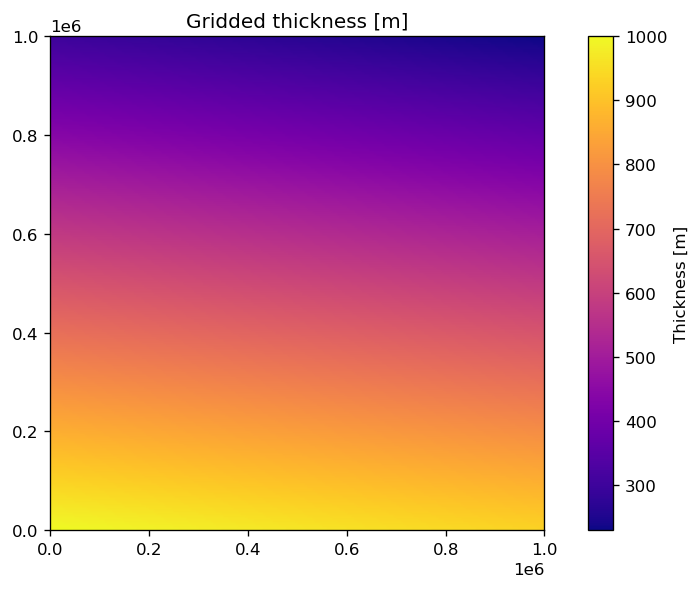

In [10]:
fig, ax, im = pyissm.plot.plot_gridded(
    md, md.geometry.thickness,
    posting=5000, colormap='plasma'
)
ax.set_title('Gridded thickness [m]')
fig.colorbar(im, ax=ax, label='Thickness [m]')
plt.show()

---
## 9  Element and vertex numbering

Label elements/vertices — useful for debugging small meshes.

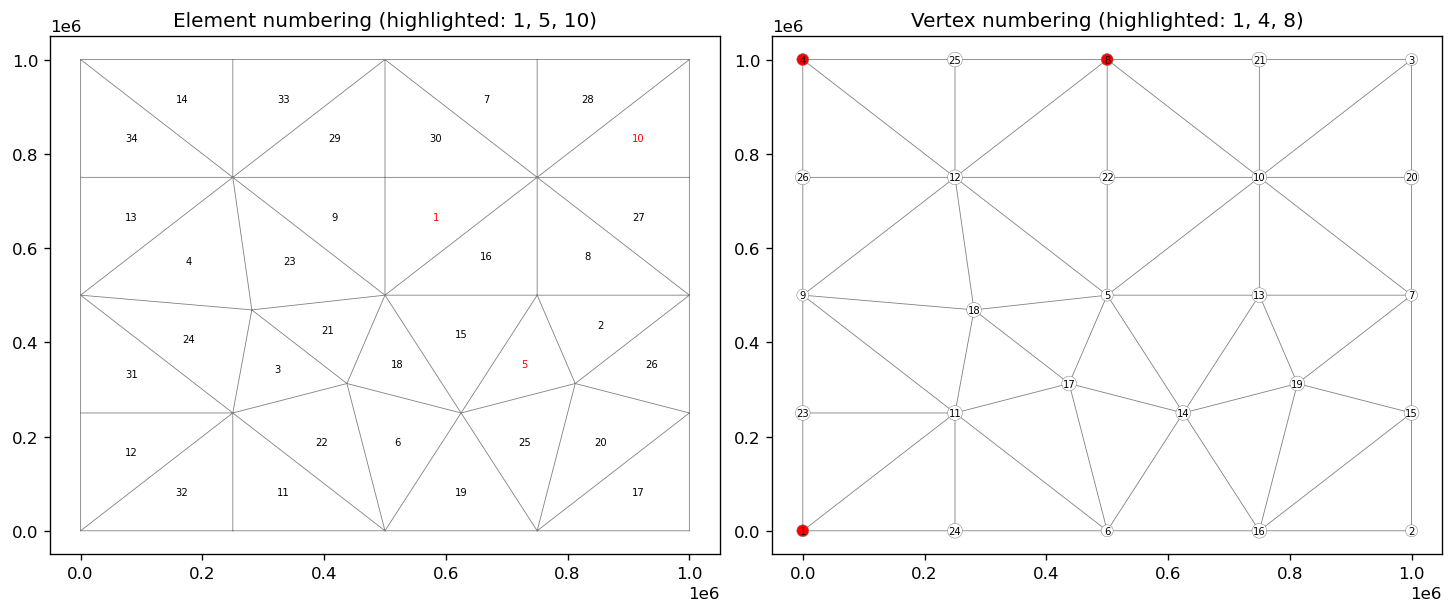

In [11]:
# Build a tiny mesh for legibility
md_tiny = pyissm.model.mesh.triangle(
    pyissm.model.Model(), '../assets/Exp/Square.exp', 200000
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

pyissm.plot.plot_elementnumbering(md_tiny, ax=axes[0], highlight=[1, 5, 10])
axes[0].set_title('Element numbering (highlighted: 1, 5, 10)')

pyissm.plot.plot_vertexnumbering(md_tiny, ax=axes[1], highlight=[1, 4, 8])
axes[1].set_title('Vertex numbering (highlighted: 1, 4, 8)')

plt.show()

---
## 10  Ice front and grounding line

`plot_icefront` colours elements that straddle the **ice-front boundary** (sign change in `ocean_levelset`) or the **grounding line** (sign change in `ice_levelset`).

> **Note:** the square shelf built with `set_mask(md, 'all', None)` has uniformly signed levelsets (all nodes are floating and ice-covered), so there are no interior sign changes and no elements are highlighted.  
> The function works as intended on models that have a partial grounding line or an ice front inside the mesh domain. The `plot_model_bc` function (section 4) is more useful for diagnosing this simple model.


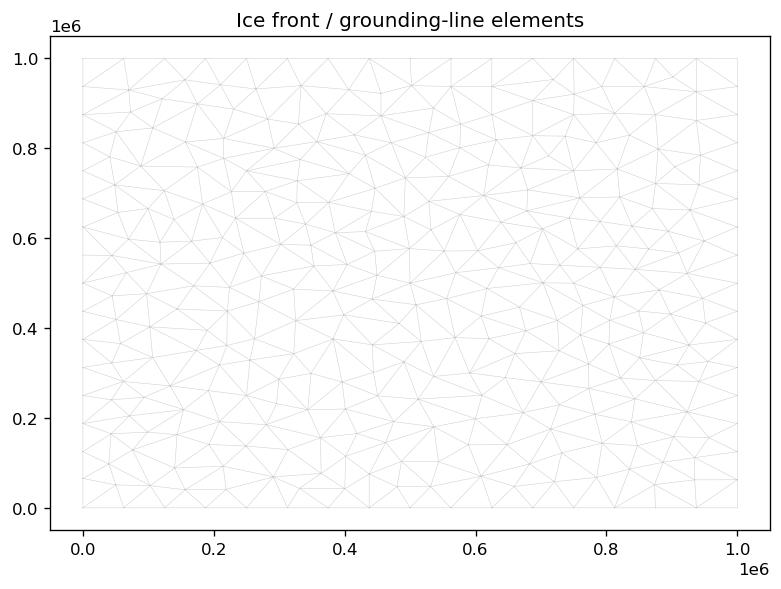

In [14]:
fig, ax = pyissm.plot.plot_icefront(
    md,
    ice_color='tab:blue',
    gl_color='tab:green',
    alpha=0.7
)
ax.set_title('Ice front / grounding-line elements')
plt.show()

---
## 11  Custom ISSM colormaps

`pyissm.plot.colormaps` exposes the ISSM DEM palette: sea (blue) for *z* < 0, land (green-brown) for *z* > 0.

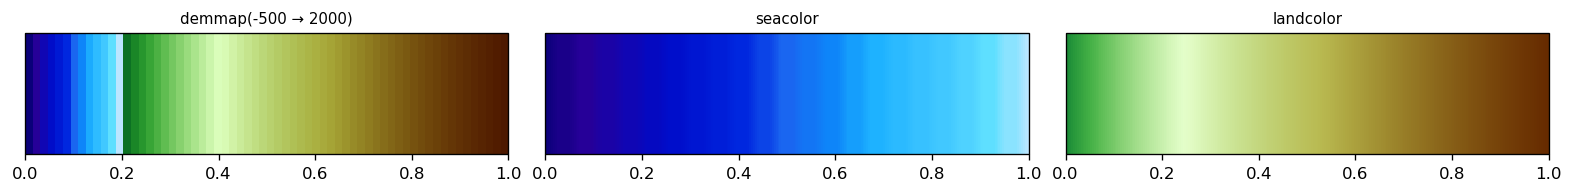

In [15]:
from pyissm.plot import colormaps as cm

cmap_dem = cm.demmap(ncolors=64, minZ=-500, maxZ=2000)

fig, axes = plt.subplots(1, 3, figsize=(13, 1.5), constrained_layout=True)

for ax, (name, cmap) in zip(axes, [
    ('demmap(-500 → 2000)', cmap_dem),
    ('seacolor',  matplotlib.colors.ListedColormap(cm.seacolor(256).T)),
    ('landcolor', matplotlib.colors.ListedColormap(cm.landcolor(256).T)),
]):
    plt.colorbar(
        plt.cm.ScalarMappable(cmap=cmap),
        cax=ax, orientation='horizontal'
    )
    ax.set_title(name, fontsize=9)

plt.show()

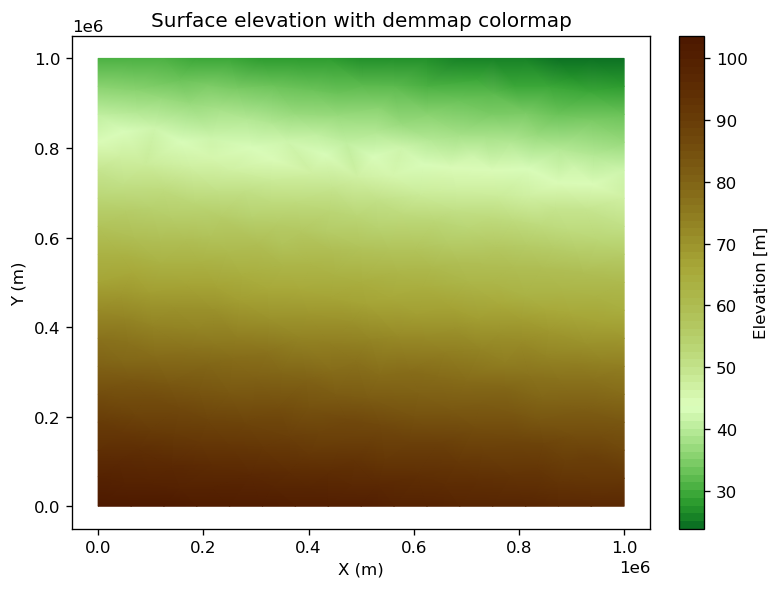

In [16]:
# Apply the DEM colormap to ice-surface elevation
z_min = md.geometry.surface.min()
z_max = md.geometry.surface.max()
cmap_surf = cm.demmap(ncolors=64, minZ=z_min, maxZ=z_max)

fig, ax, im = pyissm.plot.plot_model_field(
    md, md.geometry.surface,
    colormap=cmap_surf,
    vmin=z_min, vmax=z_max
)
ax.set_title('Surface elevation with demmap colormap')
fig.colorbar(im, ax=ax, label='Elevation [m]')
plt.show()

---
## 12  Composing multiple plots

Because every pyissm plot function accepts an existing `ax=` and returns the mappable `im`,
you can compose any combination of overlays in a standard matplotlib subplot grid.

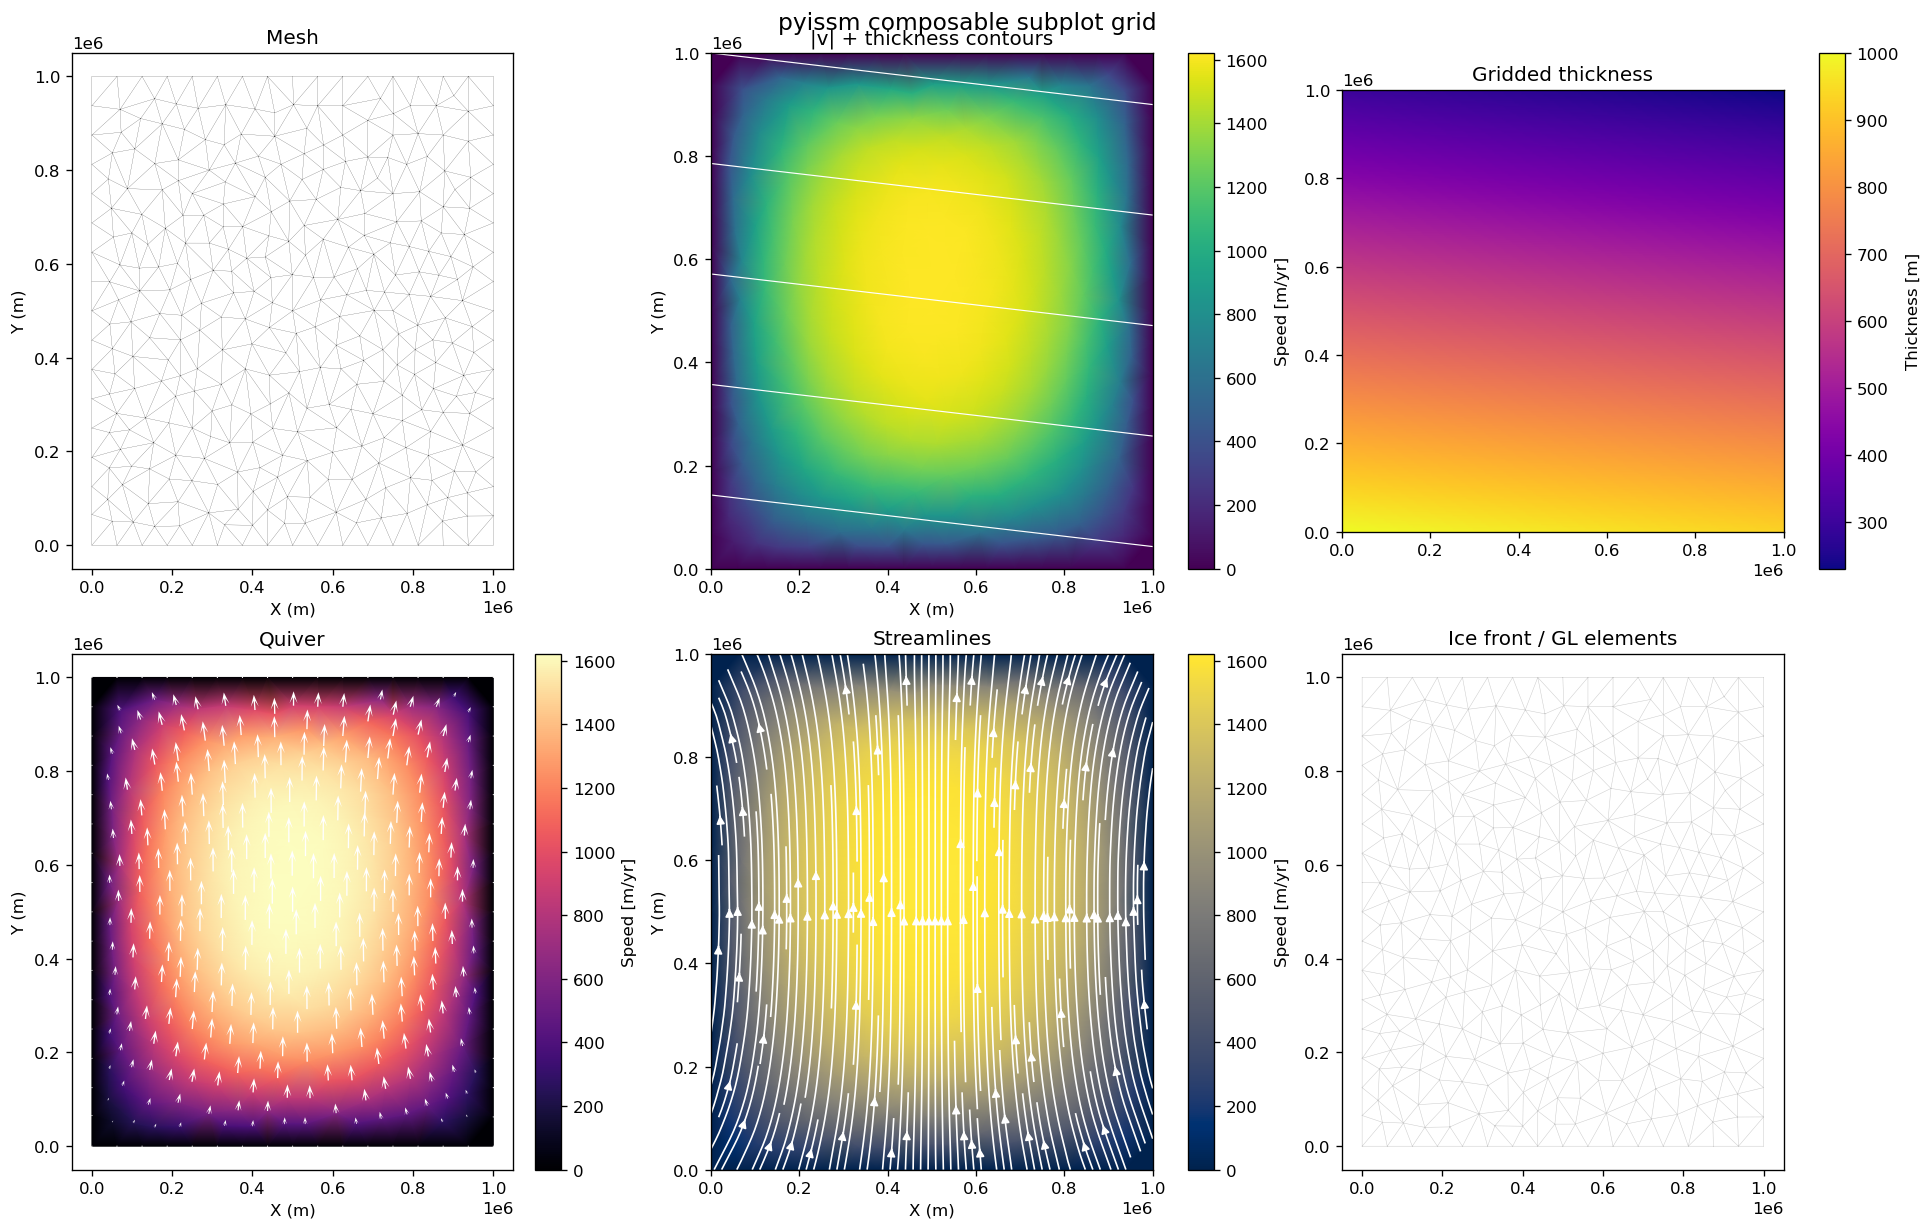

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

# ── (0,0) mesh
pyissm.plot.plot_mesh2d(md, ax=axes[0, 0])
axes[0, 0].set_title('Mesh')

# ── (0,1) velocity magnitude + thickness contours
_, _, im1 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[0, 1], colormap='viridis', show_mesh=False
)
pyissm.plot.plot_contour(
    md, md.geometry.thickness, levels=5,
    ax=axes[0, 1], colors='w', linewidths=0.7
)
fig.colorbar(im1, ax=axes[0, 1], label='Speed [m/yr]')
axes[0, 1].set_title('|v| + thickness contours')

# ── (0,2) gridded thickness
_, im2 = pyissm.plot.plot_gridded(
    md, md.geometry.thickness, ax=axes[0, 2],
    posting=5000, colormap='plasma'
)
fig.colorbar(im2, ax=axes[0, 2], label='Thickness [m]')
axes[0, 2].set_title('Gridded thickness')

# ── (1,0) quiver
_, _, im3 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[1, 0], colormap='magma', show_mesh=False
)
pyissm.plot.plot_quiver(
    md, ax=axes[1, 0], color='w', width=3e-3
)
fig.colorbar(im3, ax=axes[1, 0], label='Speed [m/yr]')
axes[1, 0].set_title('Quiver')

# ── (1,1) streamlines
_, _, im4 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[1, 1], colormap='cividis', show_mesh=False
)
pyissm.plot.plot_streamlines(
    md, ax=axes[1, 1], color='w', density=2
)
fig.colorbar(im4, ax=axes[1, 1], label='Speed [m/yr]')
axes[1, 1].set_title('Streamlines')

# ── (1,2) ice front
pyissm.plot.plot_icefront(md, ax=axes[1, 2])
axes[1, 2].set_title('Ice front / GL elements')

plt.suptitle('pyissm composable subplot grid', fontsize=14, y=1.01)
plt.show()